In [107]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, classification_report,
    balanced_accuracy_score, roc_curve,
    precision_recall_curve, auc
)
from imblearn.over_sampling import RandomOverSampler, SMOTENC
from imblearn.combine import SMOTEENN
from imblearn.under_sampling import EditedNearestNeighbours
import joblib
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'DejaVu Sans'  # default matplotlib

In [108]:
# Input dataset
DATA_PATH = "synthetic_liver_cancer_dataset.csv"
TARGET = "liver_cancer"
OUTPUT_DIR = "output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [109]:
# Load data
df = pd.read_csv(DATA_PATH)

print("DataFrame columns:", df.columns)

# Memisahkan fitur dan target
X = df.drop(columns=[TARGET])
y = df[TARGET]

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

print(f"Feature names: {list(X.columns)}")
print(f"Target name: {TARGET}")

DataFrame columns: Index(['age', 'gender', 'bmi', 'alcohol_consumption', 'smoking_status',
       'hepatitis_b', 'hepatitis_c', 'liver_function_score',
       'alpha_fetoprotein_level', 'cirrhosis_history', 'family_history_cancer',
       'physical_activity_level', 'diabetes', 'liver_cancer'],
      dtype='object')
Features shape: (5000, 13)
Target shape: (5000,)
Feature names: ['age', 'gender', 'bmi', 'alcohol_consumption', 'smoking_status', 'hepatitis_b', 'hepatitis_c', 'liver_function_score', 'alpha_fetoprotein_level', 'cirrhosis_history', 'family_history_cancer', 'physical_activity_level', 'diabetes']
Target name: liver_cancer


In [110]:
#Menampilkan 5 baris pertama
df.head()

,age,gender,bmi,alcohol_consumption,smoking_status,hepatitis_b,hepatitis_c,liver_function_score,alpha_fetoprotein_level,cirrhosis_history,family_history_cancer,physical_activity_level,diabetes,liver_cancer
0,68,Female,18.1,Regular,Former,0,0,51.9,16.44,0,0,Low,0,0
1,81,Female,19.9,Occasional,Never,0,0,41.6,8.09,0,0,Moderate,1,0
2,58,Female,25.5,Never,Never,0,0,76.0,0.64,0,0,Moderate,0,0
3,44,Male,16.0,Never,Former,0,0,50.3,19.09,0,0,Low,1,0
4,72,Male,21.0,Occasional,Former,0,0,39.5,4.95,1,0,Low,1,1


Distribusi kelas target:
              count  percentage
liver_cancer                   
0              3911       78.22
1              1089       21.78

Imbalance ratio: 3.59:1


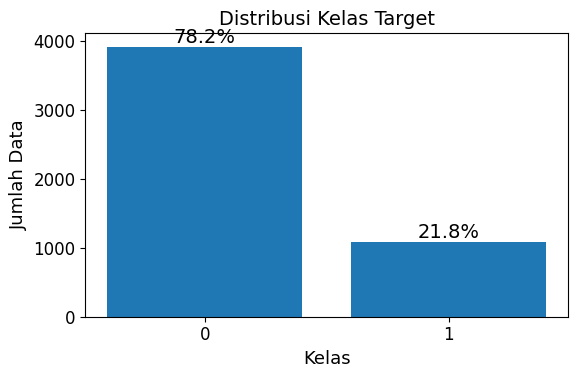

In [111]:
# Cek distribusi kelas
class_counts = df[TARGET].value_counts()
class_percent = df[TARGET].value_counts(normalize=True) * 100

# Gabungkan jadi tabel ringkas
imbalance_summary = pd.DataFrame({
    "count": class_counts,
    "percentage": class_percent.round(2)
})
imbalance_summary.to_csv("imbalanced_summary.csv")

print("Distribusi kelas target:")
print(imbalance_summary)

# Calculate imbalance ratio
if len(class_counts) == 2:
    majority_count = class_counts.max()
    minority_count = class_counts.min()
    imbalance_ratio = majority_count / minority_count
    print(f"\nImbalance ratio: {imbalance_ratio:.2f}:1")

# Plot distribusi kelas
plt.figure(figsize=(6,4))
bars = plt.bar(class_counts.index.astype(str), class_counts.values)
plt.title("Distribusi Kelas Target")
plt.xlabel("Kelas")
plt.ylabel("Jumlah Data")

# Tambahkan persentase di atas bar
for bar, pct in zip(bars, class_percent.values):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{pct:.1f}%",
        ha="center", va="bottom"
    )

plt.tight_layout()
plt.savefig("imbalanced_plot.png")  # simpan chart ke file
plt.show()

In [112]:
# Split data
print("\nData Splitting (80:20)")
print("-" * 30)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)
print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")
print(f"Training target distribution:\n{y_train.value_counts()}")
print(f"Test target distribution:\n{y_test.value_counts()}")

# Verify stratification
train_ratio = y_train.value_counts(normalize=True).sort_index()
test_ratio = y_test.value_counts(normalize=True).sort_index()
print(f"Training class ratios: {dict(train_ratio.round(3))}")
print(f"Test class ratios: {dict(test_ratio.round(3))}")

X_train.to_csv(f"{OUTPUT_DIR}/X_train.csv", index=False)
X_test.to_csv(f"{OUTPUT_DIR}/X_test.csv", index=False)
y_train.to_csv(f"{OUTPUT_DIR}/y_train.csv", index=False)
y_test.to_csv(f"{OUTPUT_DIR}/y_test.csv", index=False)

# Preview
X_train.head()


Data Splitting (80:20)
------------------------------
Training set shape: (3500, 13)
Test set shape: (1500, 13)
Training target distribution:
liver_cancer
0    2738
1     762
Name: count, dtype: int64
Test target distribution:
liver_cancer
0    1173
1     327
Name: count, dtype: int64
Training class ratios: {0: np.float64(0.782), 1: np.float64(0.218)}
Test class ratios: {0: np.float64(0.782), 1: np.float64(0.218)}


,age,gender,bmi,alcohol_consumption,smoking_status,hepatitis_b,hepatitis_c,liver_function_score,alpha_fetoprotein_level,cirrhosis_history,family_history_cancer,physical_activity_level,diabetes
3301,67,Male,23.7,Never,Former,0,0,59.7,3.54,0,1,Low,1
513,84,Female,25.8,Occasional,Current,0,0,45.6,10.82,0,1,Low,0
3968,37,Female,27.1,Occasional,Never,0,0,55.2,1.38,1,1,Low,0
571,34,Male,34.0,Never,Former,0,0,62.4,10.05,1,1,Low,0
4481,65,Female,36.5,Occasional,Former,0,0,56.7,35.66,1,0,Low,0


In [113]:
# Preview
X_test.head()

,age,gender,bmi,alcohol_consumption,smoking_status,hepatitis_b,hepatitis_c,liver_function_score,alpha_fetoprotein_level,cirrhosis_history,family_history_cancer,physical_activity_level,diabetes
3504,70,Female,15.2,Regular,Former,1,0,60.0,12.05,0,1,High,0
4018,40,Female,17.8,Never,Never,0,0,79.9,18.40,0,1,Low,1
3142,42,Female,28.7,Occasional,Never,0,0,86.9,93.50,0,0,Low,0
3959,42,Female,27.3,Never,Former,0,1,51.8,9.70,0,0,Low,0
1399,36,Female,30.4,Never,Former,0,0,42.4,1.31,0,0,Low,0


In [114]:
# Statistik deskriptif
print("\nDescriptive statistics (data training)")
print("-" * 40)
desc_stats = X_train.describe().T.round(3)
print(desc_stats)


Descriptive statistics (data training)
----------------------------------------
                          count    mean     std   min    25%    50%     75%  \
age                      3500.0  56.960  15.826  30.0  43.75  57.00  70.000   
bmi                      3500.0  25.918   5.083   9.3  22.50  25.90  29.300   
hepatitis_b              3500.0   0.155   0.362   0.0   0.00   0.00   0.000   
hepatitis_c              3500.0   0.094   0.292   0.0   0.00   0.00   0.000   
liver_function_score     3500.0  65.131  14.954   5.5  54.80  65.20  74.900   
alpha_fetoprotein_level  3500.0  15.037  15.230   0.0   4.27  10.24  20.932   
cirrhosis_history        3500.0   0.305   0.461   0.0   0.00   0.00   1.000   
family_history_cancer    3500.0   0.244   0.430   0.0   0.00   0.00   0.000   
diabetes                 3500.0   0.199   0.399   0.0   0.00   0.00   0.000   

                           max  
age                       84.0  
bmi                       43.7  
hepatitis_b                1.

In [115]:
numerical_cols = ['age', 'bmi', 'liver_function_score', 'alpha_fetoprotein_level']

ks_results = []

for col in numerical_cols:
    mean = X_train[col].mean()
    std = X_train[col].std()

    stat, p = stats.kstest(X_train[col], 'norm', args=(mean, std))

    ks_results.append({
        'Fitur': col,
        'Statistik': stat,
        'p-value': p,
        'Distribusi': 'Normal' if p > 0.05 else 'Tidak normal'
    })

result_df = pd.DataFrame(ks_results)
print(result_df)


                     Fitur  Statistik       p-value    Distribusi
0                      age   0.062596  2.299628e-12  Tidak normal
1                      bmi   0.015052  4.020498e-01        Normal
2     liver_function_score   0.010518  8.295332e-01        Normal
3  alpha_fetoprotein_level   0.161745  1.811474e-80  Tidak normal


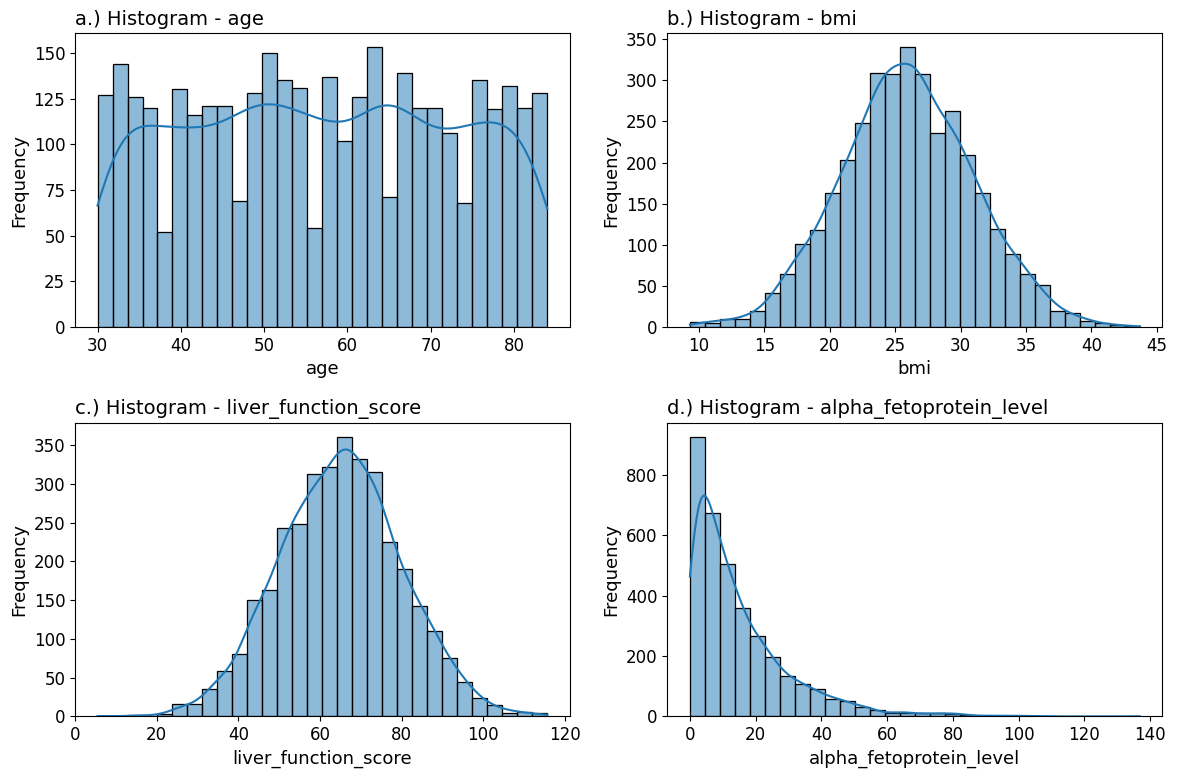

In [116]:
import math
import string
import matplotlib.pyplot as plt
import seaborn as sns

# ================= FONT LEBIH GEDE =================
plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 14,
    "axes.labelsize": 13,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12
})

# ================= SUBPLOT SETUP =================
cols = 2
rows = math.ceil(len(numerical_cols) / cols)

plt.figure(figsize=(12, 4 * rows))

for i, col in enumerate(numerical_cols):
    plt.subplot(rows, cols, i + 1)

    sns.histplot(X_train[col], bins=30, kde=True)

    # Label subplot a.) b.) c.) ...
    plt.title(f"{string.ascii_lowercase[i]}.) Histogram - {col}", loc="left")

    plt.xlabel(col)
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


In [117]:
# Cek dan penanganan missing values
print("\nCek dan Penanganan Missing Values")
print("-" * 35)

# Cek missing values
print("Missing values pada data training:")
print(X_train.isnull().sum())

print("\nMissing values pada data testing:")
print(X_test.isnull().sum())

# Hitung persentase missing per kolom
print("\nMissing values per column (data training):")
for col in X_train.columns:
    missing_count_train = X_train[col].isnull().sum()
    missing_pct_train = (missing_count_train / len(X_train)) * 100
    print(f"  {col}: {missing_count_train} ({missing_pct_train:.1f}%)")

print("\nMissing values per column (data testing):")
for col in X_train.columns:
    missing_count_test = X_test[col].isnull().sum()
    missing_pct_test = (missing_count_test / len(X_test)) * 100
    print(f"  {col}: {missing_count_test} ({missing_pct_test:.1f}%)")


Cek dan Penanganan Missing Values
-----------------------------------
Missing values pada data training:
age                        0
gender                     0
bmi                        0
alcohol_consumption        0
smoking_status             0
hepatitis_b                0
hepatitis_c                0
liver_function_score       0
alpha_fetoprotein_level    0
cirrhosis_history          0
family_history_cancer      0
physical_activity_level    0
diabetes                   0
dtype: int64

Missing values pada data testing:
age                        0
gender                     0
bmi                        0
alcohol_consumption        0
smoking_status             0
hepatitis_b                0
hepatitis_c                0
liver_function_score       0
alpha_fetoprotein_level    0
cirrhosis_history          0
family_history_cancer      0
physical_activity_level    0
diabetes                   0
dtype: int64

Missing values per column (data training):
  age: 0 (0.0%)
  gender: 0 (0.0%)



Cek Outlier
-----------------------------------
  age: train=0 (0.0%), test=0 (0.0%)
  bmi: train=32 (0.9%), test=11 (0.7%)
  liver_function_score: train=21 (0.6%), test=10 (0.7%)
  alpha_fetoprotein_level: train=171 (4.9%), test=69 (4.6%)


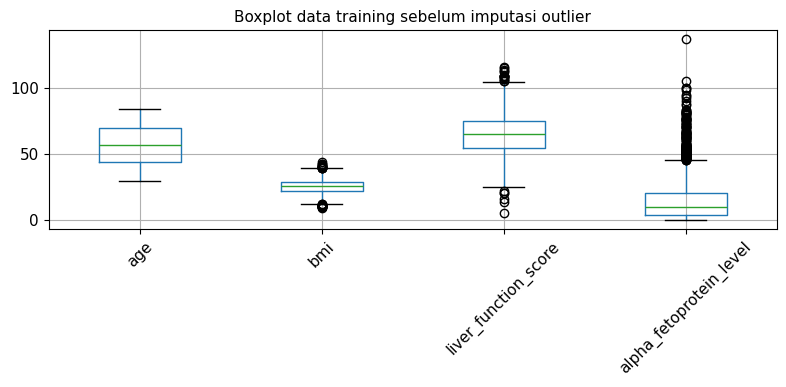

In [118]:
print("\nCek Outlier")
print("-" * 35)

outlier_info_train = {}
# tidak perlu X_train_no_outliers di sini kalau cuma cek
for col in numerical_cols:
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers_train = ((X_train[col] < lower_bound) | (X_train[col] > upper_bound))
    outliers_test = ((X_test[col] < lower_bound) | (X_test[col] > upper_bound))

    outlier_count_train = outliers_train.sum()
    outlier_pct_train = (outlier_count_train / len(X_train)) * 100
    outlier_count_test = outliers_test.sum()
    outlier_pct_test = (outlier_count_test / len(X_test)) * 100

    outlier_info_train[col] = {
        'count_train': int(outlier_count_train),
        'pct_train': outlier_pct_train,
        'count_test': int(outlier_count_test),
        'pct_test': outlier_pct_test,
        'lower_bound': lower_bound,
        'upper_bound': upper_bound
    }

    print(f"  {col}: train={outlier_count_train} ({outlier_pct_train:.1f}%), test={outlier_count_test} ({outlier_pct_test:.1f}%)")

import matplotlib.pyplot as plt

import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.size": 11
})

plt.figure(figsize=(8, 4))  # <-- INI KUNCINYA
X_train[numerical_cols].boxplot()
plt.title("Boxplot data training sebelum imputasi outlier", fontsize=11)
plt.xticks(rotation=45, fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.show()

age: imputasi=median | train replaced=0 | test replaced=0
bmi: imputasi=mean | train replaced=32 | test replaced=11
liver_function_score: imputasi=mean | train replaced=21 | test replaced=10
alpha_fetoprotein_level: imputasi=median | train replaced=171 | test replaced=69


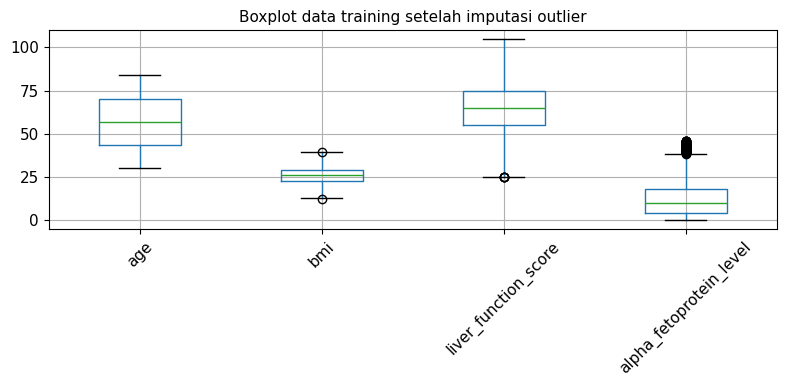

In [119]:
numerical_cols = ['age', 'bmi', 'liver_function_score', 'alpha_fetoprotein_level']
X_train_imp = X_train.copy()
X_test_imp  = X_test.copy()

for col in numerical_cols:
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

    # Mask
    train_mask = (X_train[col] < lower) | (X_train[col] > upper)
    test_mask  = (X_test[col] < lower) | (X_test[col] > upper)

    # Pilih imputasi
    if col in ["bmi", "liver_function_score"]:
        fill_value = X_train[col].mean()
        method = "mean"
    else:
        fill_value = X_train[col].median()
        method = "median"

    # Imputasi
    X_train_imp.loc[train_mask, col] = fill_value
    X_test_imp.loc[test_mask, col]   = fill_value

    print(f"{col}: imputasi={method} | train replaced={train_mask.sum()} | test replaced={test_mask.sum()}")

import matplotlib.pyplot as plt

# ================= FONT & STYLE (WORD / SKRIPSI) =================
plt.rcParams.update({
    "font.size": 11
})

# ================= VISUALISASI =================
plt.figure(figsize=(8, 4))  # ukuran dikunci biar font 11 terasa
X_train_imp[numerical_cols].boxplot()
plt.title("Boxplot data training setelah imputasi outlier", fontsize=11)
plt.xticks(rotation=45, fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.show()

# Update
X_train, X_test = X_train_imp, X_test_imp


In [120]:
X_train_imp.describe()

,age,bmi,hepatitis_b,hepatitis_c,liver_function_score,alpha_fetoprotein_level,cirrhosis_history,family_history_cancer,diabetes
count,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000
mean,56.959714,25.935369,0.154857,0.094286,65.022355,12.549191,0.305429,0.244000,0.199143
std,15.826215,4.876820,0.361820,0.292268,14.522768,10.584528,0.460655,0.429554,0.399413
min,30.000000,12.400000,0.000000,0.000000,24.900000,0.000000,0.000000,0.000000,0.000000
25%,43.750000,22.600000,0.000000,0.000000,54.900000,4.270000,0.000000,0.000000,0.000000
50%,57.000000,25.900000,0.000000,0.000000,65.130514,10.230000,0.000000,0.000000,0.000000
75%,70.000000,29.300000,0.000000,0.000000,74.800000,17.980000,1.000000,0.000000,0.000000
max,84.000000,39.400000,1.000000,1.000000,104.600000,45.850000,1.000000,1.000000,1.000000


In [121]:
# Copy X_train dan X_test setelah penanganan outlier
X_train_clean = X_train.copy()
X_test_clean = X_test.copy()

# Tentukan kolom kategori
cat_label_col = 'gender'
cat_ohe_cols = ['alcohol_consumption', 'smoking_status', 'physical_activity_level']

# Cek kolom mana yang benar-benar ada di dataset
cat_ohe_cols = [c for c in cat_ohe_cols if c in X_train_clean.columns]

print("Kolom OHE yang ditemukan:", cat_ohe_cols)

# 3. Label Encoding untuk 'gender'
le = LabelEncoder()

X_train_clean[cat_label_col] = X_train_clean[cat_label_col].astype(str)
X_test_clean[cat_label_col] = X_test_clean[cat_label_col].astype(str)

le.fit(pd.concat([X_train_clean[cat_label_col], X_test_clean[cat_label_col]], axis=0))

X_train_clean[cat_label_col] = le.transform(X_train_clean[cat_label_col])
X_test_clean[cat_label_col] = le.transform(X_test_clean[cat_label_col])

# 4. One-Hot Encoding (drop_first=True)
X_train_enc = pd.get_dummies(X_train_clean, columns=cat_ohe_cols, drop_first=False)
X_test_enc  = pd.get_dummies(X_test_clean,  columns=cat_ohe_cols, drop_first=False)
X_train_enc = X_train_enc.astype(int)
X_test_enc  = X_test_enc.astype(int)

train_cols = X_train_enc.columns
test_cols = X_test_enc.columns

missing_in_test = set(train_cols) - set(test_cols)
for c in missing_in_test:
    X_test_enc[c] = 0

missing_in_train = set(test_cols) - set(train_cols)
for c in missing_in_train:
    X_train_enc[c] = 0

X_test_enc = X_test_enc[train_cols]
X_train = X_train_enc
X_test = X_test_enc

print("Categorical features encoded successfully.")
print(f"X_train shape after encoding: {X_train.shape}")
print(f"X_test shape after encoding: {X_test.shape}")


Kolom OHE yang ditemukan: ['alcohol_consumption', 'smoking_status', 'physical_activity_level']
Categorical features encoded successfully.
X_train shape after encoding: (3500, 19)
X_test shape after encoding: (1500, 19)


In [122]:
X_train_enc.head()

,age,gender,bmi,hepatitis_b,hepatitis_c,liver_function_score,alpha_fetoprotein_level,cirrhosis_history,family_history_cancer,diabetes,alcohol_consumption_Never,alcohol_consumption_Occasional,alcohol_consumption_Regular,smoking_status_Current,smoking_status_Former,smoking_status_Never,physical_activity_level_High,physical_activity_level_Low,physical_activity_level_Moderate
3301,67,1,23,0,0,59,3,0,1,1,1,0,0,0,1,0,0,1,0
513,84,0,25,0,0,45,10,0,1,0,0,1,0,1,0,0,0,1,0
3968,37,0,27,0,0,55,1,1,1,0,0,1,0,0,0,1,0,1,0
571,34,1,34,0,0,62,10,1,1,0,1,0,0,0,1,0,0,1,0
4481,65,0,36,0,0,56,35,1,0,0,0,1,0,0,1,0,0,1,0


In [123]:
scaler = StandardScaler()
# fit scaler hanya pada data training
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])

# transform hanya pada data testing
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

print("Normalisasi (Min-Max Scaling) berhasil dilakukan untuk kolom:", numerical_cols)
print(f"Final X_train shape: {X_train.shape}")
print(f"Final X_test shape: {X_test.shape}")


Normalisasi (Min-Max Scaling) berhasil dilakukan untuk kolom: ['age', 'bmi', 'liver_function_score', 'alpha_fetoprotein_level']
Final X_train shape: (3500, 19)
Final X_test shape: (1500, 19)


In [124]:
X_train

,age,gender,bmi,hepatitis_b,hepatitis_c,liver_function_score,alpha_fetoprotein_level,cirrhosis_history,family_history_cancer,diabetes,alcohol_consumption_Never,alcohol_consumption_Occasional,alcohol_consumption_Regular,smoking_status_Current,smoking_status_Former,smoking_status_Never,physical_activity_level_High,physical_activity_level_Low,physical_activity_level_Moderate
3301,0.634499,1,-0.508087,0,0,-0.384063,-0.857202,0,1,1,1,0,0,0,1,0,0,1,0
513,1.708820,0,-0.099093,0,0,-1.348058,-0.195468,0,1,0,0,1,0,1,0,0,0,1,0
3968,-1.261361,0,0.309900,0,0,-0.659490,-1.046269,1,1,0,0,1,0,0,0,1,0,1,0
571,-1.450947,1,1.741378,0,0,-0.177493,-0.195468,1,1,0,1,0,0,0,1,0,0,1,0
4481,0.508109,0,2.150371,0,0,-0.590633,2.167868,1,0,0,0,1,0,0,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1511,0.255327,1,-0.099093,0,0,-0.934917,-0.006401,0,1,1,0,1,0,0,0,1,0,0,1
944,0.381718,1,-0.508087,1,0,0.442218,-0.857202,0,0,1,0,1,0,0,1,0,0,0,1
3052,1.392843,1,-0.099093,1,0,1.612782,-0.951736,0,0,0,1,0,0,0,1,0,0,1,0
4664,-1.071775,0,-1.939564,0,0,-0.039780,0.844400,0,0,0,0,1,0,0,0,1,0,1,0


In [125]:
def get_specificity(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tn / (tn + fp) if (tn + fp) > 0 else 0

In [127]:
results_rf = []

for i in range(25):
    rf = RandomForestClassifier(random_state=i, class_weight="balanced")
    rf.fit(X_train, y_train)
    y_pred_rf = rf.predict(X_test)

    cm = confusion_matrix(y_test, y_pred_rf)

    results_rf.append({
        "iter": i,
        "balanced accuracy": np.round(balanced_accuracy_score(y_test, y_pred_rf), 4),
        "precision": np.round(precision_score(y_test, y_pred_rf, average="binary", zero_division=0), 4),
        "recall": np.round(recall_score(y_test, y_pred_rf, average="binary", zero_division=0), 4),
        "f1": np.round(f1_score(y_test, y_pred_rf, average="binary", zero_division=0), 4),
        "specificity": get_specificity(y_test, y_pred_rf),
        "confusion_matrix": cm  # bisa juga diubah ke string: str(cm)
    })

print("Hasil Random Forest:")
print(pd.DataFrame(results_rf))


Hasil Random Forest:
    iter  balanced accuracy  precision  recall      f1  specificity  \
0      0             0.7950     0.9469  0.5994  0.7341     0.990622   
1      1             0.7952     0.9653  0.5963  0.7372     0.994032   
2      2             0.7849     0.9691  0.5749  0.7217     0.994885   
3      3             0.7871     0.9596  0.5810  0.7238     0.993180   
4      4             0.7860     0.9643  0.5780  0.7228     0.994032   
5      5             0.7925     0.9698  0.5902  0.7338     0.994885   
6      6             0.7873     0.9793  0.5780  0.7269     0.996590   
7      7             0.7885     0.9412  0.5872  0.7232     0.989770   
8      8             0.7925     0.9698  0.5902  0.7338     0.994885   
9      9             0.7886     0.9598  0.5841  0.7262     0.993180   
10    10             0.7925     0.9698  0.5902  0.7338     0.994885   
11    11             0.7987     0.9704  0.6024  0.7434     0.994885   
12    12             0.8052     0.9757  0.6147  0.7542  

Random Oversampling

In [128]:
# === 1. Random Oversampling ===
ros = RandomOverSampler(random_state=42)
X_res_ros, y_res_ros = ros.fit_resample(X_train, y_train)

print("Sebelum oversampling:", y_train.value_counts().to_dict())
print("Sesudah oversampling :", y_res_ros.value_counts().to_dict())

Sebelum oversampling: {0: 2738, 1: 762}
Sesudah oversampling : {0: 2738, 1: 2738}


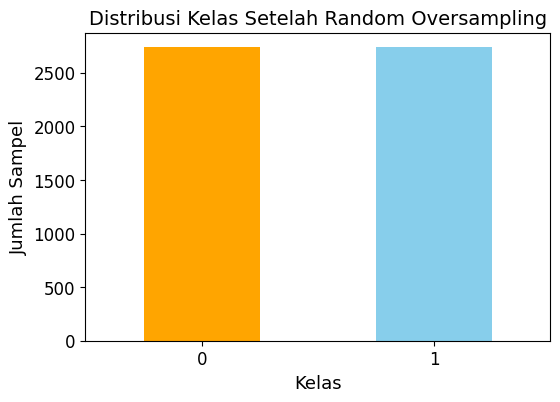

In [129]:
plt.figure(figsize=(6,4))
y_res_ros.value_counts().plot(
    kind='bar',
    color=['orange', 'skyblue']  # sesuai jumlah kelas
)
plt.title("Distribusi Kelas Setelah Random Oversampling")
plt.xlabel("Kelas")
plt.ylabel("Jumlah Sampel")
plt.xticks(rotation=0)
plt.show()


In [130]:
results_rf_ros = []

for i in range(25):
    rf = RandomForestClassifier(random_state=i)
    rf.fit(X_res_ros, y_res_ros)
    y_pred = rf.predict(X_test)

    results_rf_ros.append({
        "iter": i,
        "balanced accuracy": np.round(balanced_accuracy_score(y_test, y_pred), 4),
        "precision": np.round(precision_score(y_test, y_pred, average="binary", zero_division=0), 4),
        "recall": np.round(recall_score(y_test, y_pred, average="binary", zero_division=0), 4),
        "f1": np.round(f1_score(y_test, y_pred, average="binary", zero_division=0), 4),
        "specificity": get_specificity(y_test, y_pred)
    })

pd.DataFrame(results_rf_ros).to_csv(f"{OUTPUT_DIR}/rf_results.csv", index=False)
print("Hasil Random Forest+ROS:")
print(pd.DataFrame(results_rf_ros))

Hasil Random Forest+ROS:
    iter  balanced accuracy  precision  recall      f1  specificity
0      0             0.8582     0.8746  0.7462  0.8053     0.970162
1      1             0.8642     0.8978  0.7523  0.8186     0.976130
2      2             0.8663     0.9145  0.7523  0.8255     0.980392
3      3             0.8542     0.8889  0.7339  0.8040     0.974425
4      4             0.8557     0.8893  0.7370  0.8060     0.974425
5      5             0.8621     0.8817  0.7523  0.8119     0.971867
6      6             0.8535     0.8951  0.7309  0.8047     0.976130
7      7             0.8428     0.8923  0.7095  0.7905     0.976130
8      8             0.8498     0.9008  0.7217  0.8014     0.977835
9      9             0.8539     0.8985  0.7309  0.8061     0.976982
10    10             0.8623     0.8942  0.7492  0.8153     0.975277
11    11             0.8581     0.8963  0.7401  0.8107     0.976130
12    12             0.8566     0.8959  0.7370  0.8087     0.976130
13    13             0.

In [131]:
rf = RandomForestClassifier(random_state=0)
rf.fit(X_res_ros, y_res_ros)

rf.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': 0,
 'verbose': 0,
 'warm_start': False}

SMOTE-NC

In [132]:
# Identifikasi kolom kategorikal (pada data setelah encoding) =====
categorical_features = [
    "hepatitis_b","hepatitis_c", "cirrhosis_history", "family_history_cancer",
    "diabetes", "gender_Male", "alcohol_consumption_Occasional",
    "alcohol_consumption_Regular", "smoking_status_Former", "smoking_status_Never",
    "physical_activity_level_Low", "physical_activity_level_Moderate"
]

# Ambil indeks kolom kategorikal di X_train_enc
categorical_indices = [
    X_train.columns.get_loc(col)
    for col in categorical_features if col in X_train.columns
]

print(f"Kolom kategorikal yang dipakai: {categorical_features}")
print(f"Indeks kolom kategorikal: {categorical_indices}")

# ===== Terapkan SMOTENC =====
smote_nc = SMOTENC(categorical_features=categorical_indices, random_state=42)

X_trainres, y_trainres = smote_nc.fit_resample(X_train, y_train)

print("Distribusi kelas sebelum SMOTENC:")
print(pd.Series(y_train).value_counts())
print("\nDistribusi kelas sesudah SMOTENC:")
print(pd.Series(y_trainres).value_counts())


Kolom kategorikal yang dipakai: ['hepatitis_b', 'hepatitis_c', 'cirrhosis_history', 'family_history_cancer', 'diabetes', 'gender_Male', 'alcohol_consumption_Occasional', 'alcohol_consumption_Regular', 'smoking_status_Former', 'smoking_status_Never', 'physical_activity_level_Low', 'physical_activity_level_Moderate']
Indeks kolom kategorikal: [3, 4, 7, 8, 9, 11, 12, 14, 15, 17, 18]
Distribusi kelas sebelum SMOTENC:
liver_cancer
0    2738
1     762
Name: count, dtype: int64

Distribusi kelas sesudah SMOTENC:
liver_cancer
0    2738
1    2738
Name: count, dtype: int64


In [133]:
# Ubah hasil SMOTENC jadi DataFrame
X_trainres_df = pd.DataFrame(
    X_trainres,
    columns=X_train.columns
)

y_trainres_df = pd.Series(
    y_trainres,
    name=y_train.name if y_train.name else "target"
)

# Tampilkan di Colab
print("Shape X setelah SMOTENC:", X_trainres_df.shape)
display(X_trainres_df)

print("\nDistribusi kelas setelah SMOTENC:")
display(y_trainres_df.value_counts())

Shape X setelah SMOTENC: (5476, 19)


,age,gender,bmi,hepatitis_b,hepatitis_c,liver_function_score,alpha_fetoprotein_level,cirrhosis_history,family_history_cancer,diabetes,alcohol_consumption_Never,alcohol_consumption_Occasional,alcohol_consumption_Regular,smoking_status_Current,smoking_status_Former,smoking_status_Never,physical_activity_level_High,physical_activity_level_Low,physical_activity_level_Moderate
0,0.634499,1,-0.508087,0,0,-0.384063,-0.857202,0,1,1,1,0,0,0,1,0,0,1,0
1,1.708820,0,-0.099093,0,0,-1.348058,-0.195468,0,1,0,0,1,0,1,0,0,0,1,0
2,-1.261361,0,0.309900,0,0,-0.659490,-1.046269,1,1,0,0,1,0,0,0,1,0,1,0
3,-1.450947,1,1.741378,0,0,-0.177493,-0.195468,1,1,0,1,0,0,0,1,0,0,1,0
4,0.508109,0,2.150371,0,0,-0.590633,2.167868,1,0,0,0,1,0,0,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5471,0.660981,1,1.717617,0,0,-0.585781,-0.122903,1,0,0,1,0,0,0,0,0,0,0,1
5472,-0.811158,1,-0.827509,0,0,-1.051008,-0.361094,1,1,0,0,0,1,0,0,1,0,0,0
5473,-1.554852,0,-1.326074,0,0,1.479711,-0.918100,1,1,1,0,0,1,0,0,0,0,1,0
5474,-0.842808,0,1.413957,0,0,1.488612,0.750909,1,0,0,0,0,1,0,0,0,0,0,1



Distribusi kelas setelah SMOTENC:


,count
liver_cancer,
0,2738
1,2738


In [134]:
n_before = X_train.shape[0]
synthetic_samples = X_trainres_df.iloc[n_before:]

print("Jumlah data sintetis:", synthetic_samples.shape[0])
display(synthetic_samples.head())

Jumlah data sintetis: 1976


,age,gender,bmi,hepatitis_b,hepatitis_c,liver_function_score,alpha_fetoprotein_level,cirrhosis_history,family_history_cancer,diabetes,alcohol_consumption_Never,alcohol_consumption_Occasional,alcohol_consumption_Regular,smoking_status_Current,smoking_status_Former,smoking_status_Never,physical_activity_level_High,physical_activity_level_Low,physical_activity_level_Moderate
3500,0.116159,0,0.629049,0,0,0.128186,-0.902558,1,1,0,0,0,1,0,1,0,0,0,1
3501,0.765017,0,1.437793,0,0,0.379986,-0.549238,0,1,1,0,1,0,0,0,0,0,0,1
3502,-0.136255,0,-1.828446,0,0,-1.391446,1.488651,1,0,0,0,1,0,0,0,1,0,0,1
3503,1.253597,1,-0.261990,0,0,0.965057,1.789734,1,1,0,0,0,0,0,0,1,0,0,0
3504,0.818840,1,0.272396,1,0,-0.477578,1.480128,1,0,1,0,1,0,0,0,1,0,1,0


In [135]:
results_rf_smotenc = []

for i in range(25):
    rf = RandomForestClassifier(random_state=i)
    rf.fit(X_trainres, y_trainres)
    y_pred_rf_smotenc = rf.predict(X_test)

    results_rf_smotenc.append({
        "iter": i,
        "balanced accuracy": np.round(balanced_accuracy_score(y_test, y_pred_rf_smotenc), 4),
        "precision": np.round(precision_score(y_test, y_pred_rf_smotenc, average="binary", zero_division=0), 4),
        "recall": np.round(recall_score(y_test, y_pred_rf_smotenc, average="binary", zero_division=0), 4),
        "f1": np.round(f1_score(y_test, y_pred_rf_smotenc, average="binary", zero_division=0), 4),
        "specificity": get_specificity(y_test, y_pred_rf_smotenc)
    })

print("Hasil Random Forest+SMOTENC:")
print(pd.DataFrame(results_rf_smotenc))


Hasil Random Forest+SMOTENC:
    iter  balanced accuracy  precision  recall      f1  specificity
0      0             0.8403     0.7110  0.7676  0.7382     0.913043
1      1             0.8445     0.7115  0.7768  0.7427     0.912191
2      2             0.8418     0.7119  0.7706  0.7401     0.913043
3      3             0.8447     0.7188  0.7737  0.7452     0.915601
4      4             0.8417     0.7047  0.7737  0.7376     0.909633
5      5             0.8521     0.7155  0.7920  0.7518     0.912191
6      6             0.8498     0.7307  0.7798  0.7544     0.919864
7      7             0.8490     0.7265  0.7798  0.7522     0.918159
8      8             0.8471     0.7111  0.7829  0.7453     0.911338
9      9             0.8439     0.7025  0.7798  0.7391     0.907928
10    10             0.8390     0.7051  0.7676  0.7350     0.910486
11    11             0.8491     0.7019  0.7920  0.7443     0.906223
12    12             0.8503     0.7199  0.7859  0.7515     0.914749
13    13           

In [136]:
# Identifikasi kolom kategorikal
categorical_features = [
    "hepatitis_b","hepatitis_c", "cirrhosis_history", "family_history_cancer",
    "diabetes", 'gender_Male', "alcohol_consumption_Occasional",
    "alcohol_consumption_Regular", "smoking_status_Former", "smoking_status_Never",
    "physical_activity_level_Low", "physical_activity_level_Moderate"
]

# Dapatkan indeks kolom kategorikal (0-based)
categorical_indices = [X_train.columns.get_loc(col) for col in categorical_features if col in X_train.columns]

print(f"Kolom kategorikal yang digunakan: {categorical_features}")
print(f"Indeks kolom kategorikal: {categorical_indices}")

#SMOTENC + ENN
if categorical_indices:
    smote_nc = SMOTENC(categorical_features=categorical_indices)
else:
    from imblearn.over_sampling import SMOTE
    smote_nc = SMOTE(random_state=42)

smotenc_enn = SMOTEENN(
    smote=smote_nc,
    enn=EditedNearestNeighbours(sampling_strategy='auto')
)

# Terapkan resampling
X_res_enn, y_res_enn = smotenc_enn.fit_resample(X_train, y_train)

# Simpan hasil
pd.DataFrame(X_res_enn, columns=X_train.columns).to_csv(f"{OUTPUT_DIR}/X_train_smotenc_enn.csv", index=False)
pd.Series(y_res_enn).to_csv(f"{OUTPUT_DIR}/y_train_smotenc_enn.csv", index=False)

# Cek distribusi kelas
class_counts = pd.Series(y_res_enn).value_counts()
class_percent = pd.Series(y_res_enn).value_counts(normalize=True) * 100
print("\nDistribusi kelas setelah SMOTENC + ENN:")
print(pd.DataFrame({"count": class_counts, "percent": class_percent.round(2)}))


Kolom kategorikal yang digunakan: ['hepatitis_b', 'hepatitis_c', 'cirrhosis_history', 'family_history_cancer', 'diabetes', 'gender_Male', 'alcohol_consumption_Occasional', 'alcohol_consumption_Regular', 'smoking_status_Former', 'smoking_status_Never', 'physical_activity_level_Low', 'physical_activity_level_Moderate']
Indeks kolom kategorikal: [3, 4, 7, 8, 9, 11, 12, 14, 15, 17, 18]

Distribusi kelas setelah SMOTENC + ENN:
              count  percent
liver_cancer                
0              2738    54.23
1              2311    45.77


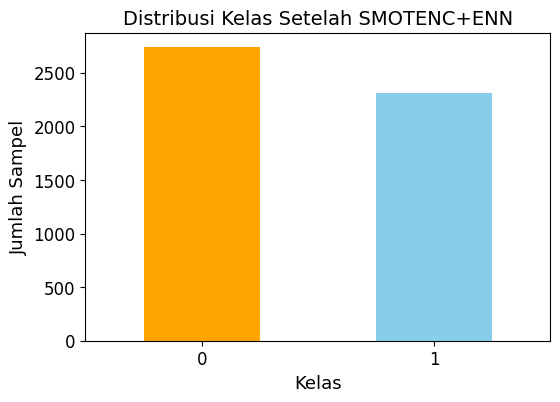

In [137]:
plt.figure(figsize=(6,4))
y_res_enn.value_counts().plot(
    kind='bar',
    color=['orange', 'skyblue']  # sesuai jumlah kelas
)
plt.title("Distribusi Kelas Setelah SMOTENC+ENN")
plt.xlabel("Kelas")
plt.ylabel("Jumlah Sampel")
plt.xticks(rotation=0)
plt.show()

In [138]:
results_rf_enn = []

for i in range(25):
    rf = RandomForestClassifier(random_state=i)
    rf.fit(X_res_enn, y_res_enn)  # fit pakai DataFrame
    y_pred_rf_enn = rf.predict(X_test)

    results_rf_enn.append({
        "iter": i,
        "balanced accuracy": round(balanced_accuracy_score(y_test, y_pred_rf_enn), 4),
        "precision": np.round(precision_score(y_test, y_pred_rf_enn, average="binary", zero_division=0), 4),
        "recall": np.round(recall_score(y_test, y_pred_rf_enn, average="binary", zero_division=0), 4),
        "f1": np.round(f1_score(y_test, y_pred_rf_enn, average="binary", zero_division=0), 4),
        "specificity": get_specificity(y_test, y_pred_rf_enn)
    })

# Simpan hasil RF ke CSV
pd.DataFrame(results_rf_enn).to_csv(f"{OUTPUT_DIR}/rf_results.csv", index=False)

print("Hasil Random Forest+SMOTENCENN:")
print(pd.DataFrame(results_rf_enn))

Hasil Random Forest+SMOTENCENN:
    iter  balanced accuracy  precision  recall      f1  specificity
0      0             0.8097     0.7442  0.6850  0.7134     0.934356
1      1             0.8088     0.7551  0.6789  0.7150     0.938619
2      2             0.8035     0.7569  0.6667  0.7089     0.940324
3      3             0.8098     0.7700  0.6758  0.7199     0.943734
4      4             0.8064     0.7492  0.6758  0.7106     0.936914
5      5             0.8055     0.7604  0.6697  0.7122     0.941176
6      6             0.8105     0.7492  0.6850  0.7157     0.936061
7      7             0.8167     0.7525  0.6972  0.7238     0.936061
8      8             0.8107     0.7585  0.6820  0.7182     0.939471
9      9             0.8024     0.7587  0.6636  0.7080     0.941176
10    10             0.8086     0.7458  0.6820  0.7125     0.935209
11    11             0.8066     0.7586  0.6728  0.7131     0.940324
12    12             0.8086     0.7458  0.6820  0.7125     0.935209
13    13        

In [139]:
X_train.var().sort_values(ascending=False).head(2)

,0
bmi,1.000286
alpha_fetoprotein_level,1.000286


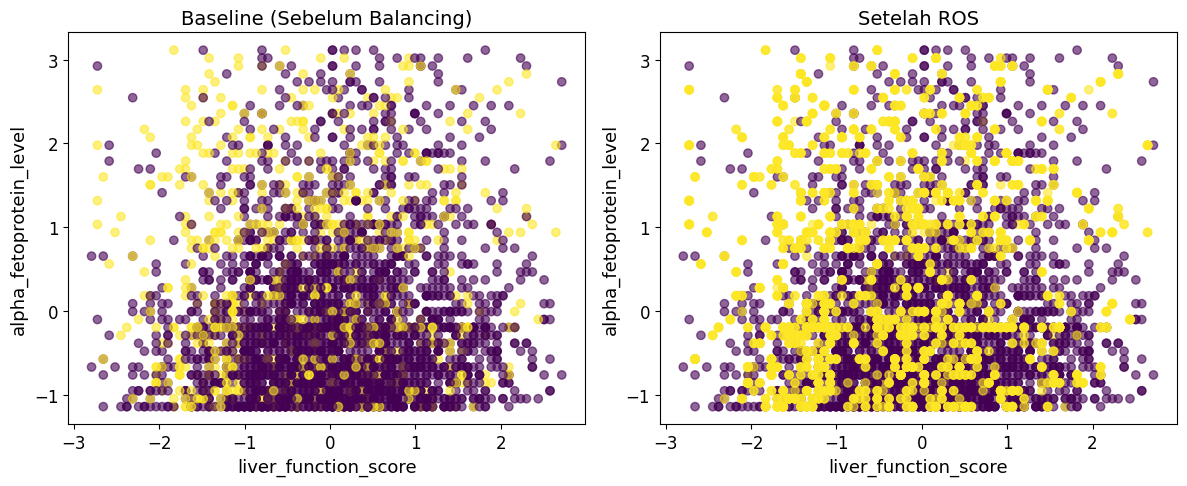

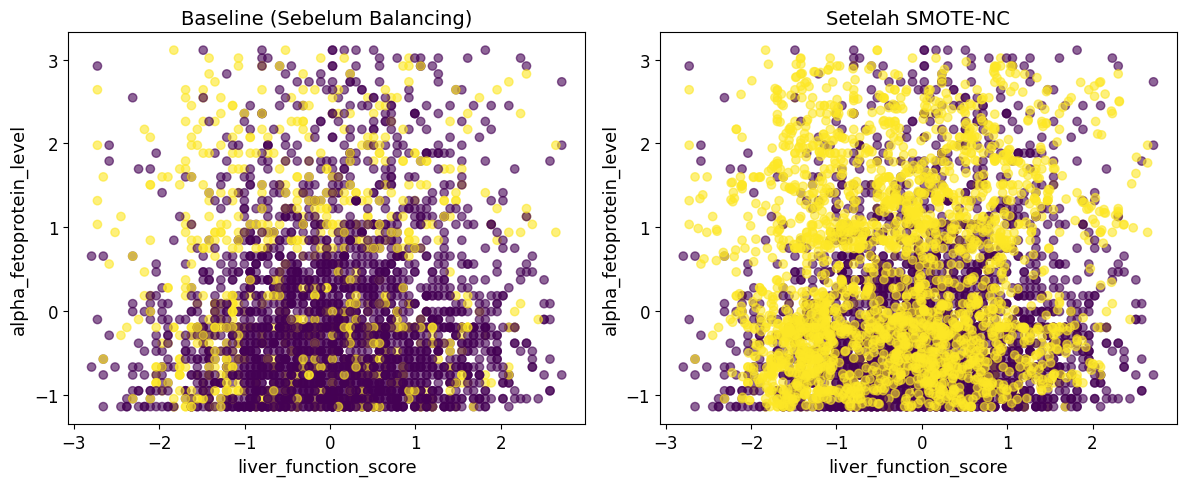

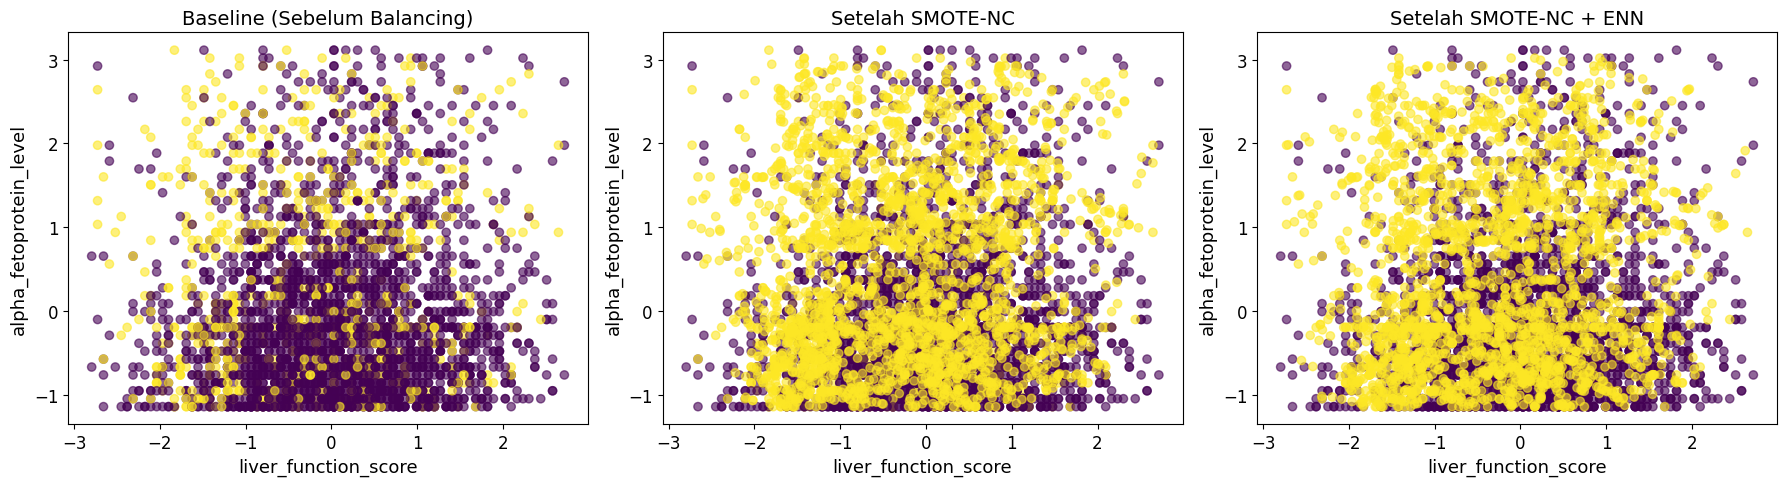

In [140]:
# Pilih dua fitur numerik untuk scatter plot
f1 = "liver_function_score"
f2 = "alpha_fetoprotein_level"

# Buat DataFrame untuk plotting
df_before = pd.concat([X_train, y_train.rename('label')], axis=1)
df_ros = pd.concat([pd.DataFrame(X_res_ros, columns=X_train.columns), y_res_ros.rename('label')], axis=1)
df_smotenc = pd.concat([pd.DataFrame(X_trainres, columns=X_train.columns), y_trainres.rename('label')], axis=1)
df_enn = pd.concat([pd.DataFrame(X_res_enn, columns=X_train.columns), y_res_enn.rename('label')], axis=1)

# =====================================================
# 1. Baseline vs ROS
# =====================================================
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.scatter(df_before[f1], df_before[f2], c=df_before['label'], alpha=0.6)
plt.title("Baseline (Sebelum Balancing)")
plt.xlabel(f1); plt.ylabel(f2)

plt.subplot(1,2,2)
plt.scatter(df_ros[f1], df_ros[f2], c=df_ros['label'], alpha=0.6)
plt.title("Setelah ROS")
plt.xlabel(f1); plt.ylabel(f2)

plt.tight_layout()
plt.show()

# =====================================================
# 2. Baseline vs SMOTE-NC
# =====================================================
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.scatter(df_before[f1], df_before[f2], c=df_before['label'], alpha=0.6)
plt.title("Baseline (Sebelum Balancing)")
plt.xlabel(f1); plt.ylabel(f2)

plt.subplot(1,2,2)
plt.scatter(df_smotenc[f1], df_smotenc[f2], c=df_smotenc['label'], alpha=0.6)
plt.title("Setelah SMOTE-NC")
plt.xlabel(f1); plt.ylabel(f2)

plt.tight_layout()
plt.show()

plt.figure(figsize=(18,5))

# --- Baseline ---
plt.subplot(1,3,1)
plt.scatter(df_before[f1], df_before[f2], c=df_before['label'], alpha=0.6)
plt.title("Baseline (Sebelum Balancing)")
plt.xlabel(f1); plt.ylabel(f2)

# --- SMOTE-NC ---
plt.subplot(1,3,2)
plt.scatter(df_smotenc[f1], df_smotenc[f2], c=df_smotenc['label'], alpha=0.6)
plt.title("Setelah SMOTE-NC")
plt.xlabel(f1); plt.ylabel(f2)

# --- SMOTE-NC + ENN ---
plt.subplot(1,3,3)
plt.scatter(df_enn[f1], df_enn[f2], c=df_enn['label'], alpha=0.6)
plt.title("Setelah SMOTE-NC + ENN")
plt.xlabel(f1); plt.ylabel(f2)

plt.tight_layout()
plt.show()

In [141]:
def ci_t95(series):
    series = series.dropna().astype(float)
    mean = series.mean()
    sd = series.std(ddof=1)
    se = sd / np.sqrt(n)
    margin = t_crit * se
    return mean, sd, se, margin, mean - margin, mean + margin

In [142]:
metrics_list = ["precision", "recall", "f1",
           "specificity", "balanced accuracy"]

# Combine all results into a single DataFrame
df_base = pd.DataFrame(results_rf)
df_base["Model"] = "Baseline"

df_ros = pd.DataFrame(results_rf_ros)
df_ros["Model"] = "ROS"

df_smotenc = pd.DataFrame(results_rf_smotenc)
df_smotenc["Model"] = "SMOTENC"

df_enn = pd.DataFrame(results_rf_enn)
df_enn["Model"] = "SMOTENC+ENN"

df_all = pd.concat([df_base, df_ros, df_smotenc, df_enn], ignore_index=True)


# To calculate the t-distribution critical value
alpha = 0.05  # Significance level for 95% CI
n = 25        # Number of iterations
df_degree = n - 1  # Degrees of freedom
t_crit = stats.t.ppf(1 - alpha / 2, df_degree) # T-critical value for 95% CI


rows = []

for model_name in df_all["Model"].unique():

    df_m = df_all[df_all["Model"] == model_name]

    for metric in metrics_list:
        mean, sd, se, margin, ci_low, ci_up = ci_t95(df_m[metric])

        rows.append({
            "model": model_name,
            "metric": metric,
            "mean": mean,
            "sd": sd,
            "se": se,
            "margin": margin,
            "ci_lower": ci_low,
            "ci_upper": ci_up,
            "ci_text": f"{mean:.3f} \u00B1 {margin:.3f} (95% CI: {ci_low:.3f}, {ci_up:.3f})"
        })

CI_df = pd.DataFrame(rows)

In [143]:
CI_df.to_csv("CI_summary.csv", index=False)
CI_df

,model,metric,mean,sd,se,margin,ci_lower,ci_upper,ci_text
0,Baseline,precision,0.963120,0.010264,0.002053,0.004237,0.958883,0.967357,"0.963 ± 0.004 (95% CI: 0.959, 0.967)"
1,Baseline,recall,0.590092,0.012533,0.002507,0.005173,0.584919,0.595265,"0.590 ± 0.005 (95% CI: 0.585, 0.595)"
2,Baseline,f1,0.731736,0.010679,0.002136,0.004408,0.727328,0.736144,"0.732 ± 0.004 (95% CI: 0.727, 0.736)"
3,Baseline,specificity,0.993691,0.001808,0.000362,0.000746,0.992945,0.994438,"0.994 ± 0.001 (95% CI: 0.993, 0.994)"
4,Baseline,balanced accuracy,0.791888,0.006472,0.001294,0.002671,0.789217,0.794559,"0.792 ± 0.003 (95% CI: 0.789, 0.795)"
5,ROS,precision,0.892772,0.009398,0.001880,0.003879,0.888893,0.896651,"0.893 ± 0.004 (95% CI: 0.889, 0.897)"
6,ROS,recall,0.744960,0.013594,0.002719,0.005611,0.739349,0.750571,"0.745 ± 0.006 (95% CI: 0.739, 0.751)"
7,ROS,f1,0.812116,0.009561,0.001912,0.003947,0.808169,0.816063,"0.812 ± 0.004 (95% CI: 0.808, 0.816)"
8,ROS,specificity,0.975038,0.002430,0.000486,0.001003,0.974035,0.976042,"0.975 ± 0.001 (95% CI: 0.974, 0.976)"
9,ROS,balanced accuracy,0.860004,0.006878,0.001376,0.002839,0.857165,0.862843,"0.860 ± 0.003 (95% CI: 0.857, 0.863)"
